# Evaluation: Utility, Fidelity and Privacy

The final step in the pipeline. It measures every synthetic dataset across the three
evaluation dimensions from the methodology, in one place, because the argument rests on
reading them together. A synthetic dataset can look good on one dimension and poor on
another, so keeping them in a single notebook keeps the full picture in view.

Four parts:

1. Utility asks whether a model trained on synthetic data still works on real patients.
2. Fidelity asks whether the synthetic data resembles the real data statistically.
3. Privacy asks whether the synthetic data reveals the real patients it was learned from.
4. A trade-off summary brings the headline numbers together, one row per dataset.

Each method appears twice, once at its library defaults and once at the configuration its
hyperparameter search selected. Those are the project's two experiments, and reporting them
side by side is what allows the question of whether tuning changes the comparison to be
answered rather than assumed. A section after the fidelity results compares the two
configurations of each method directly.

Every dataset present is evaluated and any that is missing is skipped, so this runs whether
one experiment or both have been completed. Everything reported is an aggregate statistic or
a chart, never an individual record, so the outputs are safe to reuse directly.

## Setup

Loads the shared train and test split and whichever synthetic datasets exist, and defines
the readable labels used on every chart, so no raw column name appears in a figure.

In [1]:
%pip install -q pandas pyarrow scikit-learn scipy matplotlib seaborn

## Working folder

Sets the project folder so everything the pipeline writes, the cohort, the synthetic
datasets, the outputs and the figures, persists between sessions rather than sitting on
temporary storage.

The cohort and the synthetic datasets derive from MIMIC-IV, which is credentialed data
under a PhysioNet data use agreement. Keep the folder private, do not share it, and
delete the data once the work is finished.

In [2]:
import os
from pathlib import Path

# Use the shared project folder when one is available, otherwise stay in the
# current directory.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    project_dir = Path("/content/drive/MyDrive/mimic-synthetic-pipeline")
    project_dir.mkdir(parents=True, exist_ok=True)
    os.chdir(project_dir)
    print(f"Working folder: {project_dir}")
except ImportError:
    print("Using the local working folder.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working folder set to Google Drive: /content/drive/MyDrive/mimic-synthetic-pipeline


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.15)
fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)
out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)

TARGET = "readmitted_30d"
NUMERIC_COLS = ["age_at_admission", "length_of_stay_days"]
CATEGORICAL_COLS = [
    "gender",
    "admission_type",
    "admission_location",
    "insurance",
    "marital_status",
    "race",
    "language",
    "had_icu_stay",
]

# Plain-English labels used on every chart in this notebook.
COLUMN_LABELS = {
    "gender": "Gender",
    "admission_type": "Admission Type",
    "admission_location": "Admission Location",
    "insurance": "Insurance",
    "marital_status": "Marital Status",
    "race": "Race",
    "language": "Language",
    "had_icu_stay": "ICU Stay",
    "age_at_admission": "Age at Admission",
    "length_of_stay_days": "Length of Stay (days)",
}

for required in ["data/train.parquet", "data/test.parquet"]:
    if not Path(required).exists():
        raise FileNotFoundError(
            f"{required} not found. Run the extraction and preparation steps first."
        )
def _coerce_ints(df):
    """Coerce pandas nullable Int64 columns to plain numpy int64 for compatibility."""
    for _c in df.columns:
        if str(df[_c].dtype) == "Int64":
            df[_c] = df[_c].astype("int64")
    return df

train_df = _coerce_ints(pd.read_parquet("data/train.parquet"))
test_df = _coerce_ints(pd.read_parquet("data/test.parquet"))

# Load whichever synthetic datasets the generation notebooks produced.
# Two datasets per method: one at library defaults, one at the configuration chosen by
# that method's search. Both are loaded so the two experiments are reported side by side.
METHOD_SLUGS = {
    "Gaussian Copula": "gaussian_copula",
    "CTGAN": "ctgan",
    "TVAE": "tvae",
    "TabDDPM": "tabddpm",
}
EXPERIMENTS = {"default": "default", "tuned": "tuned"}

METHOD_FILES = {}
for _name, _slug in METHOD_SLUGS.items():
    for _exp in EXPERIMENTS:
        METHOD_FILES[f"{_name} ({_exp})"] = f"data/synthetic_{_slug}_{_exp}.parquet"
# Only the two-experiment filenames are accepted. The single-dataset naming used earlier in
# the project is deliberately not read: those files were produced from a different train and
# test split, and scoring them against the current test set would leak training patients into
# the evaluation and inflate every result without raising an error.
synthetic = {}
for name, path in METHOD_FILES.items():
    if Path(path).exists():
        synthetic[name] = _coerce_ints(pd.read_parquet(path))
        print(f"Loaded {name}: {len(synthetic[name]):,} synthetic admissions")
    else:
        print(f"{name}: file not found, skipping ({path})")

if not synthetic:
    raise FileNotFoundError("No synthetic datasets found. Run the generation steps first.")

Loaded Gaussian Copula: 427,408 synthetic admissions
Loaded CTGAN: 427,408 synthetic admissions
Loaded TVAE: 427,408 synthetic admissions
Loaded TabDDPM: 427,408 synthetic admissions


## Part 1: Utility

The practical question: if a researcher only had the synthetic data, could they still build
a readmission model that works on real patients?

The design is train on synthetic, test on real. A model is first trained on the real
training data and scored on the real test data, which gives the baseline, the best this
model can do with genuine data. The same model is then trained on each synthetic dataset and
scored on the same real test patients. The closer a synthetic-trained model comes to the
baseline, the more predictive signal that generator preserved.

Every method contributes two rows, one for each configuration. Rows are therefore compared in
two directions: between methods within an experiment, and between the two configurations of a
single method.

### The prediction model

Logistic regression throughout, matching the methodology. The simplicity is deliberate:
with a powerful model, good results might come from the model's own capacity rather than
from the quality of the training data. Using one simple model everywhere means differences
between rows can only come from the data each row was trained on. Balanced class weighting
is used because only about 21% of admissions are followed by a readmission.

Five scores are reported. ROC AUC measures how well the model ranks readmitted patients
above non-readmitted ones and is the primary score. PR AUC summarises the precision-recall
curve and is more demanding under class imbalance, because it ignores the large majority of
true negatives that ROC AUC gets credit for; its no-skill floor is not 0.5 but the positive
rate itself, about 0.21 here. Precision, recall and F1 complete the picture.

Reporting both ROC AUC and PR AUC matters for this cohort. A generator can produce data
that yields a degenerate classifier, one predicting readmission for nearly every patient,
and such a model can still post a middling ROC AUC while its precision collapses to the
base rate. PR AUC exposes that directly.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_classifier() -> Pipeline:
    """Logistic regression with one-hot encoded categoricals and scaled numerics."""
    preprocess = ColumnTransformer(
        [
            ("num", StandardScaler(), NUMERIC_COLS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
        ]
    )
    return Pipeline(
        [
            ("preprocess", preprocess),
            ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
        ]
    )


def evaluate_model(fit_on: pd.DataFrame, test_on: pd.DataFrame) -> dict:
    """Train on one dataset, test on another, return all five utility scores."""
    clf = make_classifier()
    clf.fit(fit_on.drop(columns=[TARGET]), fit_on[TARGET])
    proba = clf.predict_proba(test_on.drop(columns=[TARGET]))[:, 1]
    pred = clf.predict(test_on.drop(columns=[TARGET]))
    y = test_on[TARGET]
    return {
        "roc_auc": roc_auc_score(y, proba),
        "pr_auc": average_precision_score(y, proba),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
    }


# The no-skill floor for PR AUC is the positive rate, not 0.5. Everything else is
# read against 0.5 or against the baseline row below.
PR_AUC_NO_SKILL = test_df[TARGET].mean()

baseline = evaluate_model(train_df, test_df)
print("Baseline (train on real, test on real):")
for metric, value in baseline.items():
    print(f"  {metric}: {value:.4f}")
print(f"\nPR AUC no-skill floor (test-set positive rate): {PR_AUC_NO_SKILL:.4f}")

Baseline (train on real, test on real):
  roc_auc: 0.6124
  pr_auc: 0.2775
  precision: 0.2642
  recall: 0.5838
  f1: 0.3637

PR AUC no-skill floor (test-set positive rate): 0.2048


### Scoring each method

Each synthetic dataset trains the identical model, which is then scored on the same real
test patients. The table also records each dataset's readmission rate, showing whether the
generator kept the outcome realistically rare, and the utility loss against the baseline.

Method names carry the configuration in brackets, so a row reading "CTGAN (tuned)" is that
method under the settings its search selected, and "CTGAN (default)" is the same method under
the library defaults.

In [5]:
utility_rows = []
for name, syn in synthetic.items():
    scores = evaluate_model(syn, test_df)
    utility_rows.append(
        {
            "method": name,
            "synthetic_readmission_rate": syn[TARGET].mean(),
            **{f"tstr_{k}": v for k, v in scores.items()},
        }
    )
    print(
        f"{name}: TSTR ROC AUC = {scores['roc_auc']:.4f} (baseline {baseline['roc_auc']:.4f}), "
        f"PR AUC = {scores['pr_auc']:.4f} (baseline {baseline['pr_auc']:.4f}, "
        f"no-skill {PR_AUC_NO_SKILL:.4f})"
    )

utility_df = pd.DataFrame(utility_rows)
for k, v in baseline.items():
    utility_df[f"trtr_{k}"] = v
utility_df["pr_auc_no_skill"] = PR_AUC_NO_SKILL
utility_df["utility_loss_roc_auc"] = utility_df["trtr_roc_auc"] - utility_df["tstr_roc_auc"]
utility_df["utility_loss_pr_auc"] = utility_df["trtr_pr_auc"] - utility_df["tstr_pr_auc"]
# Relative retention, the second form of the Chapter 3 success criterion.
utility_df["pct_of_baseline_roc_auc"] = (
    utility_df["tstr_roc_auc"] / utility_df["trtr_roc_auc"] * 100
)
utility_df.to_csv(out_dir / "utility_results.csv", index=False)
utility_df.round(4)

Gaussian Copula: TSTR ROC AUC = 0.5752 (baseline 0.6124), PR AUC = 0.2575 (baseline 0.2775, no-skill 0.2048)
CTGAN: TSTR ROC AUC = 0.5774 (baseline 0.6124), PR AUC = 0.2540 (baseline 0.2775, no-skill 0.2048)
TVAE: TSTR ROC AUC = 0.5661 (baseline 0.6124), PR AUC = 0.2437 (baseline 0.2775, no-skill 0.2048)
TabDDPM: TSTR ROC AUC = 0.5219 (baseline 0.6124), PR AUC = 0.2164 (baseline 0.2775, no-skill 0.2048)


,method,synthetic_readmission_rate,tstr_roc_auc,tstr_pr_auc,tstr_precision,tstr_recall,tstr_f1,trtr_roc_auc,trtr_pr_auc,trtr_precision,trtr_recall,trtr_f1,pr_auc_no_skill,utility_loss_roc_auc,utility_loss_pr_auc,pct_of_baseline_roc_auc
0,Gaussian Copula,0.2088,0.5752,0.2575,0.2450,0.5540,0.3398,0.6124,0.2775,0.2642,0.5838,0.3637,0.2048,0.0373,0.0200,93.9166
1,CTGAN,0.2168,0.5774,0.2540,0.2434,0.5751,0.3420,0.6124,0.2775,0.2642,0.5838,0.3637,0.2048,0.0350,0.0234,94.2874
2,TVAE,0.2026,0.5661,0.2437,0.2397,0.5346,0.3310,0.6124,0.2775,0.2642,0.5838,0.3637,0.2048,0.0463,0.0338,92.4366
3,TabDDPM,0.2064,0.5219,0.2164,0.2207,0.3639,0.2748,0.6124,0.2775,0.2642,0.5838,0.3637,0.2048,0.0906,0.0610,85.2131


Columns prefixed tstr are the train-on-synthetic scores; those prefixed trtr repeat the
real-data baseline on every row for comparison.

### Against the success criterion

The methodology sets the bar for meaningful utility in two equivalent forms: a
train-on-synthetic ROC AUC within about five percentage points of the real-data baseline,
or at least about 90% of it in relative terms. Both are applied here so it is visible
whether they agree.

The thresholds are declared as constants rather than buried in prose, so the criterion is
explicit and it is clear it was fixed in advance rather than chosen to suit the numbers.

In [6]:
# The Chapter 3 success criterion, fixed in advance rather than chosen to fit these
# results. Both forms are applied; PASS requires both, FAIL requires neither.
SUCCESS_ABS_PP = 0.05   # TSTR ROC AUC within 5 percentage points of the baseline
SUCCESS_REL_PCT = 90.0  # or retaining at least 90% of the baseline

criterion = utility_df[
    ["method", "tstr_roc_auc", "utility_loss_roc_auc", "pct_of_baseline_roc_auc"]
].copy()
criterion["meets_absolute_rule"] = criterion["utility_loss_roc_auc"] <= SUCCESS_ABS_PP
criterion["meets_relative_rule"] = criterion["pct_of_baseline_roc_auc"] >= SUCCESS_REL_PCT
criterion["verdict"] = np.select(
    [
        criterion["meets_absolute_rule"] & criterion["meets_relative_rule"],
        criterion["meets_absolute_rule"] | criterion["meets_relative_rule"],
    ],
    ["PASS", "PARTIAL"],
    default="FAIL",
)
criterion = criterion.sort_values("tstr_roc_auc", ascending=False).reset_index(drop=True)
criterion.to_csv(out_dir / "success_criterion.csv", index=False)

print(
    f"Criterion: utility loss <= {SUCCESS_ABS_PP:.2f} ROC AUC "
    f"AND >= {SUCCESS_REL_PCT:.0f}% of the baseline ({baseline['roc_auc']:.4f}).\n"
)
for _, row in criterion.iterrows():
    print(
        f"  {row['method']:<26} ROC AUC {row['tstr_roc_auc']:.4f} | "
        f"loss {row['utility_loss_roc_auc']:.4f} | "
        f"{row['pct_of_baseline_roc_auc']:.1f}% of baseline -> {row['verdict']}"
    )

n_pass = int((criterion["verdict"] == "PASS").sum())
print(f"\n{n_pass} of {len(criterion)} methods meet the criterion on both forms.")
if (criterion["meets_absolute_rule"] != criterion["meets_relative_rule"]).any():
    print(
        "Note: the two forms of the criterion disagree for at least one method, which "
        "should be reported rather than resolved by picking the more favourable one."
    )
criterion.round(4)

Criterion: utility loss <= 0.05 ROC AUC AND >= 90% of the baseline (0.6124).

  CTGAN              ROC AUC 0.5774 | loss 0.0350 | 94.3% of baseline -> PASS
  Gaussian Copula    ROC AUC 0.5752 | loss 0.0373 | 93.9% of baseline -> PASS
  TVAE               ROC AUC 0.5661 | loss 0.0463 | 92.4% of baseline -> PASS
  TabDDPM            ROC AUC 0.5219 | loss 0.0906 | 85.2% of baseline -> FAIL

3 of 4 methods meet the criterion on both forms.


,method,tstr_roc_auc,utility_loss_roc_auc,pct_of_baseline_roc_auc,meets_absolute_rule,meets_relative_rule,verdict
0,CTGAN,0.5774,0.0350,94.2874,True,True,PASS
1,Gaussian Copula,0.5752,0.0373,93.9166,True,True,PASS
2,TVAE,0.5661,0.0463,92.4366,True,True,PASS
3,TabDDPM,0.5219,0.0906,85.2131,False,False,FAIL


### How much of the gap between methods is real

The methods are separated by small margins, and a single ROC AUC is a point estimate from
one particular test set. Before claiming one method preserves more utility than another, it
is worth asking whether a difference of that size is distinguishable from sampling noise.

This uses a paired bootstrap. The test set is resampled with replacement many times, and on
each resample every method's ROC AUC is recomputed from predictions already made, so no
model is retrained and the comparison stays paired: each method is scored on exactly the
same patients in every replicate. Two things come out of it, a confidence interval for each
method's score and a confidence interval for the difference between each method and the
highest scoring one. Where a difference interval contains zero, the two methods cannot be
distinguished on this test set and should be reported as equivalent rather than ranked.

Pairing matters. Comparing independently drawn intervals would be weaker and more
conservative, because much of the variation between replicates is shared: a resample
containing harder patients lowers every score together, and pairing cancels that out.

Fitting each model once to capture predicted probabilities...
  baseline done
  Gaussian Copula done
  CTGAN done
  TVAE done
  TabDDPM done

Running 500 paired bootstrap resamples...

95% confidence intervals from 500 replicates:
  Real data (baseline)   0.6124  [0.6081, 0.6167]
  CTGAN                  0.5774  [0.5732, 0.5822]
  Gaussian Copula        0.5752  [0.5705, 0.5795]
  TVAE                   0.5661  [0.5622, 0.5702]
  TabDDPM                0.5219  [0.5179, 0.5262]

Paired differences against the best method (CTGAN):
  CTGAN minus Gaussian Copula                +0.0023 [-0.0014, +0.0061]  NOT distinguishable (interval spans 0)
  CTGAN minus TVAE                           +0.0113 [+0.0067, +0.0159]  distinguishable
  CTGAN minus TabDDPM                        +0.0555 [+0.0500, +0.0620]  distinguishable

CTGAN cannot be distinguished from: Gaussian Copula.
Report these as equivalent on utility rather than ranking them.


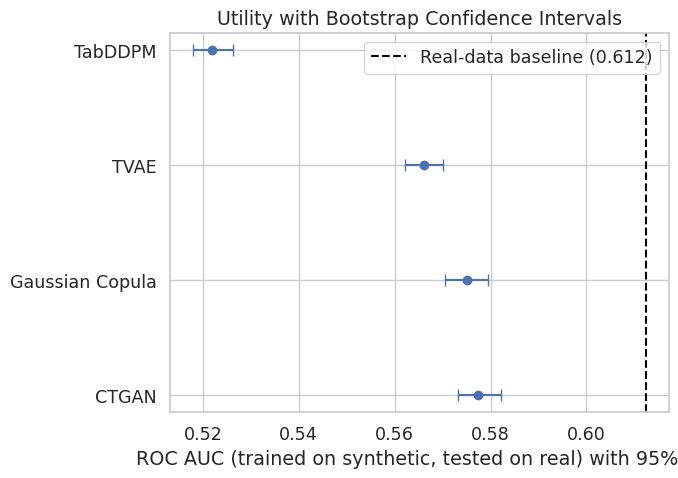

,method,roc_auc,ci_lower,ci_upper,ci_width
0,Real data (baseline),0.6124,0.6081,0.6167,0.0086
1,CTGAN,0.5774,0.5732,0.5822,0.0090
2,Gaussian Copula,0.5752,0.5705,0.5795,0.0090
3,TVAE,0.5661,0.5622,0.5702,0.0080
4,TabDDPM,0.5219,0.5179,0.5262,0.0084


In [7]:
N_BOOTSTRAP = 500     # resamples of the test set
BOOTSTRAP_SEED = 42
CI_LOW, CI_HIGH = 2.5, 97.5  # percentiles for a 95% interval

y_test = test_df[TARGET].to_numpy()
X_test = test_df.drop(columns=[TARGET])

# Fit each model once and keep its predicted probabilities. The bootstrap then
# resamples the test set only, so this costs one fit per method rather than one per
# replicate, and every method is scored on identical patients in each replicate.
print("Fitting each model once to capture predicted probabilities...", flush=True)
probabilities = {}

_clf = make_classifier()
_clf.fit(train_df.drop(columns=[TARGET]), train_df[TARGET])
probabilities["Real data (baseline)"] = _clf.predict_proba(X_test)[:, 1]
print("  baseline done", flush=True)

for name, syn in synthetic.items():
    _clf = make_classifier()
    _clf.fit(syn.drop(columns=[TARGET]), syn[TARGET])
    probabilities[name] = _clf.predict_proba(X_test)[:, 1]
    print(f"  {name} done", flush=True)

rng = np.random.default_rng(BOOTSTRAP_SEED)
model_labels = list(probabilities)
replicates = {k: [] for k in model_labels}

print(f"\nRunning {N_BOOTSTRAP} paired bootstrap resamples...", flush=True)
for _ in range(N_BOOTSTRAP):
    idx = rng.integers(0, len(y_test), len(y_test))
    y_resampled = y_test[idx]
    if y_resampled.min() == y_resampled.max():
        continue  # degenerate resample with a single class; ROC AUC undefined
    for k in model_labels:
        replicates[k].append(roc_auc_score(y_resampled, probabilities[k][idx]))

replicates = {k: np.asarray(v) for k, v in replicates.items()}

ci_rows = []
for k in model_labels:
    values = replicates[k]
    ci_rows.append({
        "method": k,
        "roc_auc": roc_auc_score(y_test, probabilities[k]),
        "ci_lower": float(np.percentile(values, CI_LOW)),
        "ci_upper": float(np.percentile(values, CI_HIGH)),
        "ci_width": float(np.percentile(values, CI_HIGH) - np.percentile(values, CI_LOW)),
    })
ci_df = pd.DataFrame(ci_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
ci_df.to_csv(out_dir / "utility_bootstrap_ci.csv", index=False)

print(f"\n95% confidence intervals from {len(next(iter(replicates.values())))} replicates:")
for _, row in ci_df.iterrows():
    print(
        f"  {row['method']:<26} {row['roc_auc']:.4f}  "
        f"[{row['ci_lower']:.4f}, {row['ci_upper']:.4f}]"
    )

# Paired differences against the best-scoring synthetic method.
synthetic_labels = [k for k in model_labels if k != "Real data (baseline)"]
best = max(synthetic_labels, key=lambda k: roc_auc_score(y_test, probabilities[k]))

diff_rows = []
for k in synthetic_labels:
    if k == best:
        continue
    differences = replicates[best] - replicates[k]
    lower = float(np.percentile(differences, CI_LOW))
    upper = float(np.percentile(differences, CI_HIGH))
    diff_rows.append({
        "comparison": f"{best} minus {k}",
        "mean_difference": float(differences.mean()),
        "ci_lower": lower,
        "ci_upper": upper,
        "distinguishable": not (lower <= 0.0 <= upper),
    })
diff_df = pd.DataFrame(diff_rows)
diff_df.to_csv(out_dir / "utility_bootstrap_differences.csv", index=False)

print(f"\nPaired differences against the best method ({best}):")
for _, row in diff_df.iterrows():
    status = "distinguishable" if row["distinguishable"] else "NOT distinguishable (interval spans 0)"
    print(
        f"  {row['comparison']:<42} {row['mean_difference']:+.4f} "
        f"[{row['ci_lower']:+.4f}, {row['ci_upper']:+.4f}]  {status}"
    )

indistinguishable = [r["comparison"].split(" minus ")[1] for r in diff_rows if not r["distinguishable"]]
print()
if indistinguishable:
    print(
        f"{best} cannot be distinguished from: {', '.join(indistinguishable)}.\n"
        "Report these as equivalent on utility rather than ranking them."
    )
else:
    print(f"{best} is distinguishable from every other method on this test set.")

fig, ax = plt.subplots(figsize=(7, 5))
plot_df = ci_df[ci_df["method"] != "Real data (baseline)"]
ax.errorbar(
    plot_df["roc_auc"],
    range(len(plot_df)),
    xerr=[plot_df["roc_auc"] - plot_df["ci_lower"], plot_df["ci_upper"] - plot_df["roc_auc"]],
    fmt="o",
    color="#4C72B0",
    capsize=4,
)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["method"])
ax.axvline(
    baseline["roc_auc"], color="black", linestyle="--",
    label=f"Real-data baseline ({baseline['roc_auc']:.3f})",
)
ax.set_xlabel("ROC AUC (trained on synthetic, tested on real) with 95% CI")
ax.set_title("Utility with Bootstrap Confidence Intervals")
ax.legend()
fig.tight_layout()
fig.savefig(fig_dir / "utility_bootstrap_ci.png", dpi=200, bbox_inches="tight")
plt.show()

ci_df.round(4)

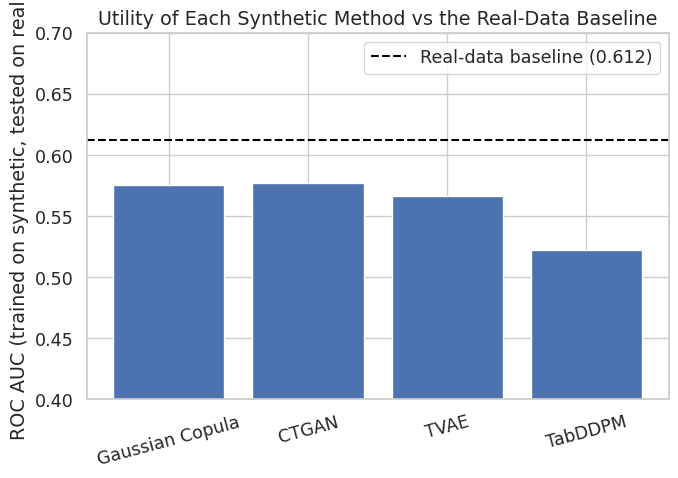

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(utility_df["method"], utility_df["tstr_roc_auc"], color="#4C72B0")
ax.axhline(baseline["roc_auc"], color="black", linestyle="--", label=f"Real-data baseline ({baseline['roc_auc']:.3f})")
ax.set_ylabel("ROC AUC (trained on synthetic, tested on real)")
ax.set_title("Utility of Each Synthetic Method vs the Real-Data Baseline")
ax.set_ylim(0.4, max(0.7, baseline["roc_auc"] + 0.05))
ax.tick_params(axis="x", rotation=15)
ax.legend()
fig.tight_layout()
fig.savefig(fig_dir / "utility_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

PR AUC is shown separately because the outcome is rare, at roughly one admission in five.
ROC AUC treats both classes alike, so a model can score respectably on it while being poor
at the thing that actually matters here, finding the patients who will be readmitted. PR AUC
is sensitive to that, and its no-skill floor is the positive rate rather than 0.5.

Where a method's two configurations disagree between the two measures, the disagreement is
worth reporting rather than resolving by picking whichever is more flattering.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(utility_df["method"], utility_df["tstr_pr_auc"], color="#55A868")
ax.axhline(
    baseline["pr_auc"], color="black", linestyle="--",
    label=f"Real-data baseline ({baseline['pr_auc']:.3f})",
)
ax.axhline(
    PR_AUC_NO_SKILL, color="#C44E52", linestyle=":",
    label=f"No-skill floor ({PR_AUC_NO_SKILL:.3f})",
)
ax.set_ylabel("PR AUC (trained on synthetic, tested on real)")
ax.set_title("Precision-Recall Performance Against the Baseline and the No-Skill Floor")
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
ax.legend()
fig.tight_layout()
fig.savefig(fig_dir / "utility_pr_auc.png", dpi=200, bbox_inches="tight")
plt.show()

Each bar is a model trained only on that method's synthetic data and tested on real
patients it has never seen. The dashed line is the real-data baseline, the practical
ceiling for this model.

## Part 2: Fidelity

Utility asked whether the synthetic data is useful. Fidelity asks whether it actually
resembles the real data statistically. A dataset can score well on one and poorly on the
other, which is why both are measured.

Three checks. The Kolmogorov-Smirnov statistic compares the distribution of each numeric
column, taking the largest gap between the two cumulative distributions, so 0 means
identical. Total variation distance does the same job for categorical columns. Correlation
comparison checks whether relationships between variables survived, not just each column on
its own, since a generator can copy every column's shape perfectly and still lose the
connections between them.

### Numeric columns

For each numeric column, the KS statistic measures the largest gap between the real and
synthetic cumulative distributions. A value near 0 means the synthetic column is shaped
almost exactly like the real one. There is no universal threshold for good, so the values
are read comparatively.

In [9]:
from scipy.stats import ks_2samp

ks_rows = []
for name, syn in synthetic.items():
    for col in NUMERIC_COLS:
        stat = ks_2samp(train_df[col].astype(float), syn[col].astype(float)).statistic
        ks_rows.append({"method": name, "column": COLUMN_LABELS[col], "ks_statistic": stat})

ks_df = pd.DataFrame(ks_rows)
ks_df.to_csv(out_dir / "fidelity_ks_numeric.csv", index=False)
ks_pivot = ks_df.pivot(index="method", columns="column", values="ks_statistic").round(4)
ks_pivot

column,Age at Admission,Length of Stay (days)
method,,
CTGAN,0.0364,0.0548
Gaussian Copula,0.0627,0.0539
TVAE,0.0349,0.0275
TabDDPM,0.1679,0.2732


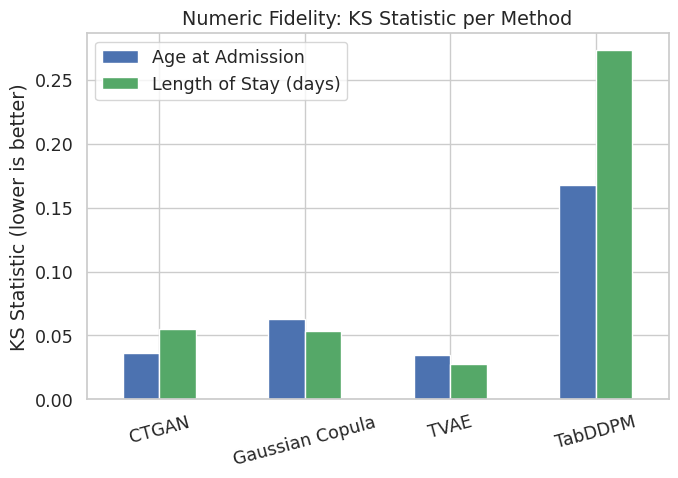

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
ks_pivot.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868"])
ax.set_ylabel("KS Statistic (lower is better)")
ax.set_xlabel("")
ax.set_title("Numeric Fidelity: KS Statistic per Method")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="")
fig.tight_layout()
fig.savefig(fig_dir / "fidelity_ks_numeric.png", dpi=200, bbox_inches="tight")
plt.show()

Each pair of bars is one method, one bar per numeric column. Shorter is better. The gap
between the two also shows which column each generator found harder; length of stay is
heavily skewed, so it is usually the more difficult.

### The distributions directly

The KS statistic is a single number, convenient but it hides where the differences are.
These overlays plot the real and synthetic distributions on top of each other, one chart per
column per method, so a shifted peak, a missing tail or an unrealistic spike is visible.
Length of stay is clipped at 30 days in the charts only, for readability.

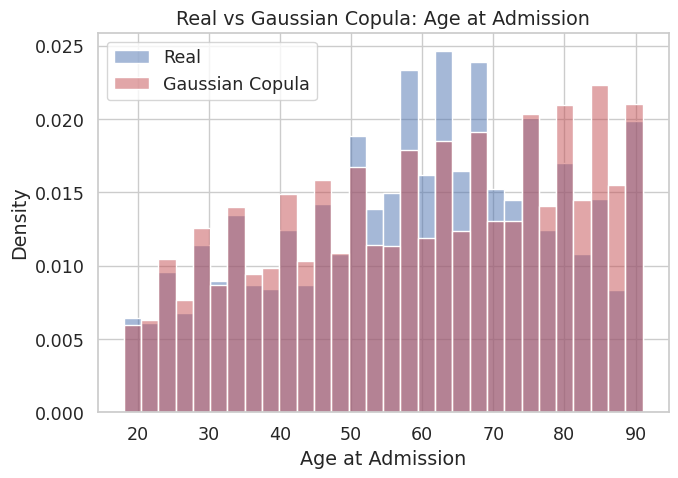

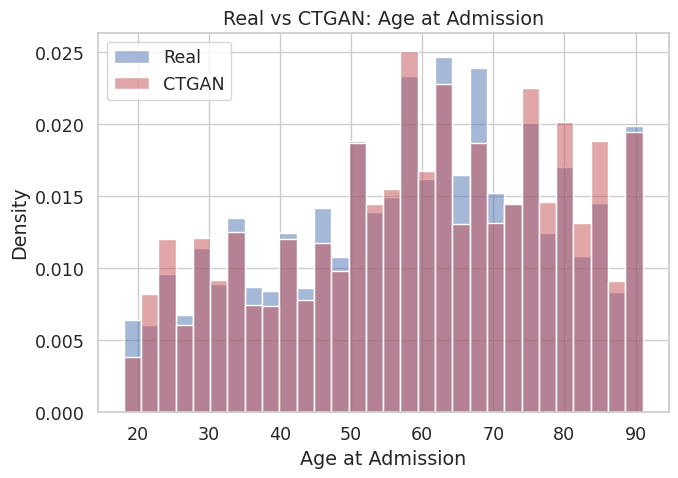

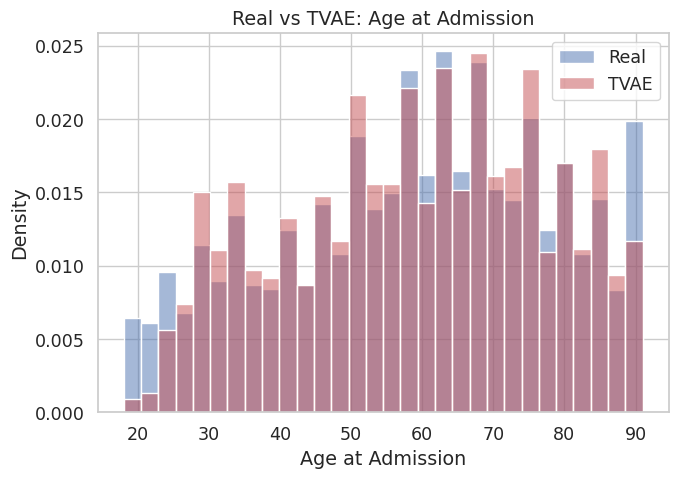

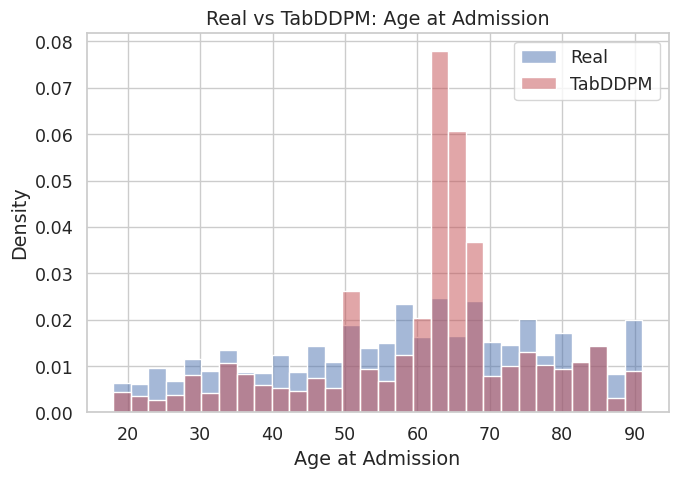

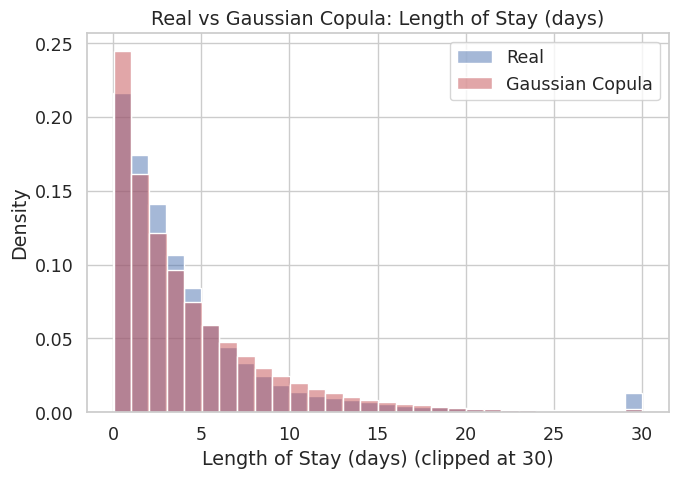

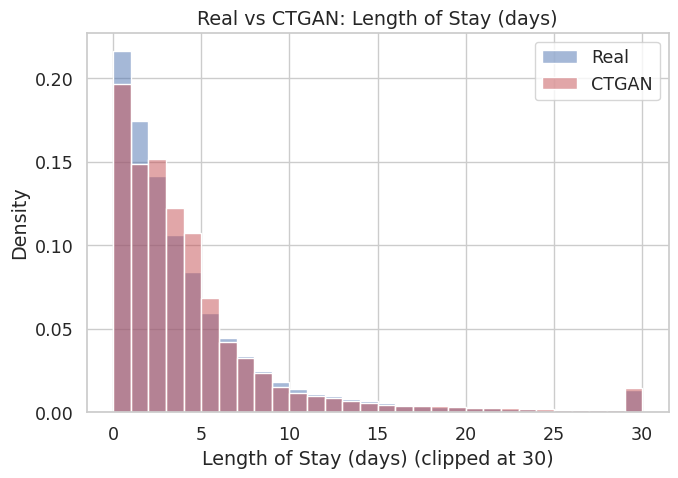

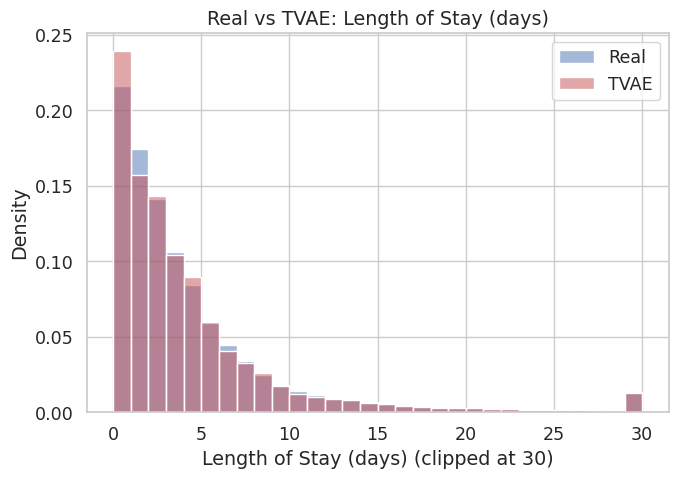

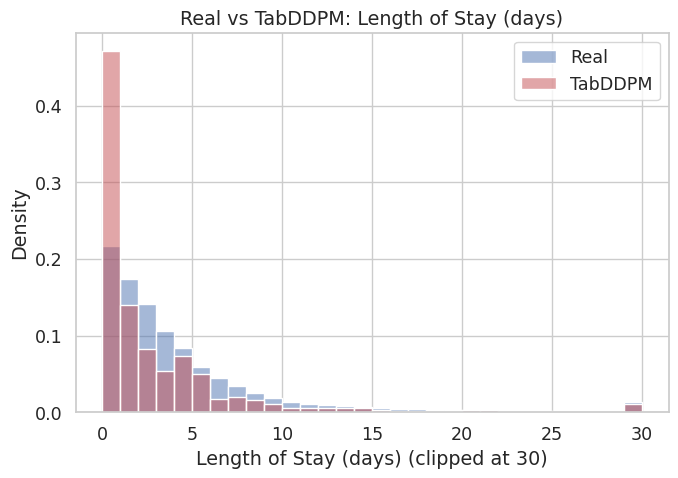

In [11]:
def overlay(col, clip_upper=None):
    real_vals = train_df[col].astype(float)
    if clip_upper is not None:
        real_vals = real_vals.clip(upper=clip_upper)
    for name, syn in synthetic.items():
        syn_vals = syn[col].astype(float)
        if clip_upper is not None:
            syn_vals = syn_vals.clip(upper=clip_upper)
        fig, ax = plt.subplots(figsize=(7, 5))
        sns.histplot(real_vals, bins=30, stat="density", color="#4C72B0", alpha=0.5, label="Real", ax=ax)
        sns.histplot(syn_vals, bins=30, stat="density", color="#C44E52", alpha=0.5, label=name, ax=ax)
        label = COLUMN_LABELS[col] + (f" (clipped at {clip_upper})" if clip_upper else "")
        ax.set_xlabel(label)
        ax.set_ylabel("Density")
        ax.set_title(f"Real vs {name}: {COLUMN_LABELS[col]}")
        ax.legend()
        fig.tight_layout()
        safe = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
        fig.savefig(fig_dir / f"fidelity_overlay_{col}_{safe}.png", dpi=200, bbox_inches="tight")
        plt.show()
        plt.close(fig)

overlay("age_at_admission")
overlay("length_of_stay_days", clip_upper=30)

Blue is the real data, red is one method's synthetic data. Heavy overlap means that part of
the distribution was reproduced well. Gaps show what the KS number was summarising.

### Categorical columns

Total variation distance compares category proportions. A TVD of 0.05 means 5% of the
synthetic records would need to change category to match the real proportions exactly.
Columns with many rare categories, such as race and language, are the hardest test, because
a generator can easily drop or overproduce small groups.

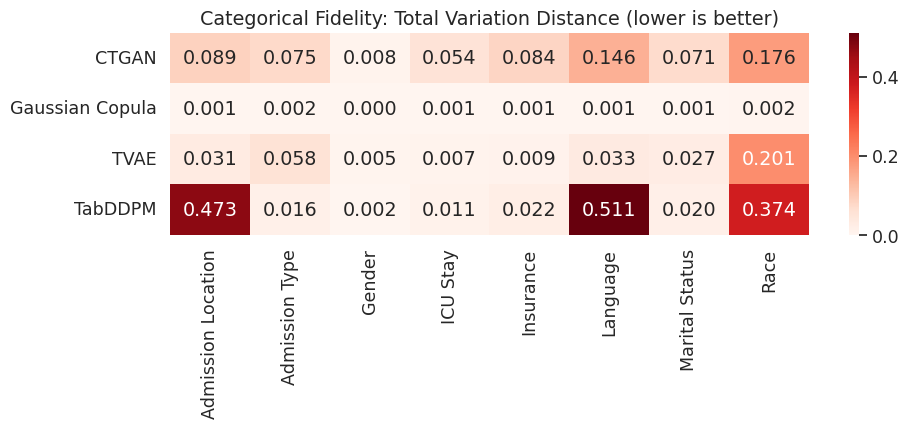

In [12]:
def tvd(real, syn):
    p = real.value_counts(normalize=True)
    q = syn.value_counts(normalize=True)
    cats = p.index.union(q.index)
    return 0.5 * sum(abs(p.get(c, 0.0) - q.get(c, 0.0)) for c in cats)


tvd_rows = []
for name, syn in synthetic.items():
    for col in CATEGORICAL_COLS:
        tvd_rows.append({
            "method": name,
            "column": COLUMN_LABELS[col],
            "tvd": tvd(train_df[col].astype(str), syn[col].astype(str)),
        })

tvd_df = pd.DataFrame(tvd_rows)
tvd_df.to_csv(out_dir / "fidelity_tvd_categorical.csv", index=False)
tvd_pivot = tvd_df.pivot(index="method", columns="column", values="tvd")

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(tvd_pivot, annot=True, fmt=".3f", cmap="Reds", vmin=0, ax=ax)
ax.set_title("Categorical Fidelity: Total Variation Distance (lower is better)")
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(fig_dir / "fidelity_tvd_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

Each cell is one method's TVD for one column. Darker means a bigger mismatch. Reading along
a row shows a method's weak spots; reading down a column shows which methods handled that
variable best.

### Relationships between variables

Using the same four numeric-compatible variables as the correlation matrix in the first
notebook. For each method the synthetic correlation matrix is subtracted from the real one.
Values near zero mean that pair of relationships was preserved. Positive means the real
relationship is stronger, so the generator weakened it; negative means it exaggerated
it.

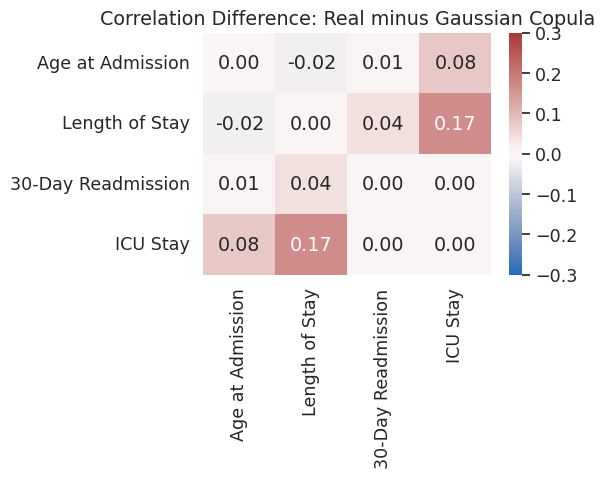

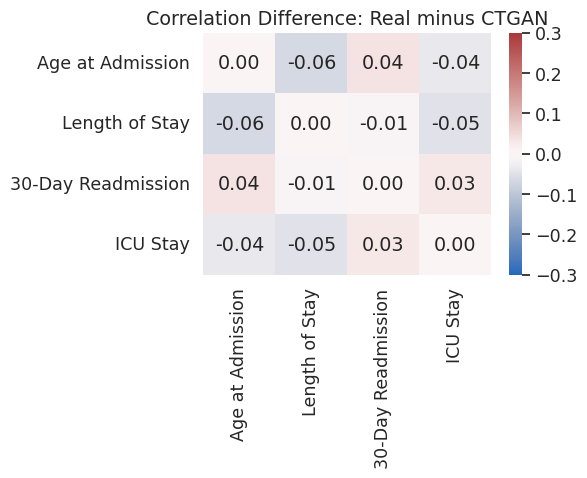

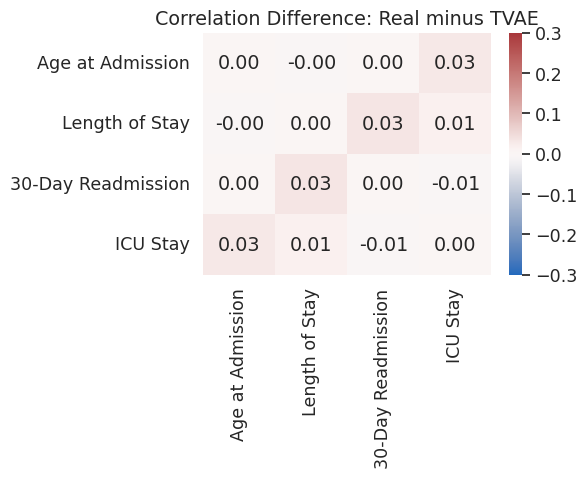

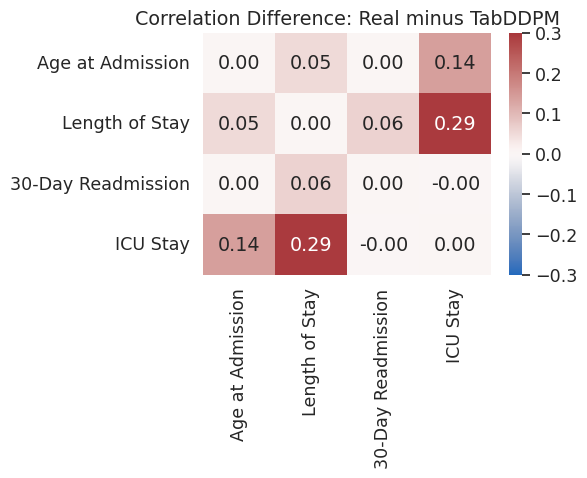

In [13]:
CORR_LABELS = ["Age at Admission", "Length of Stay", "30-Day Readmission", "ICU Stay"]


def corr_matrix(df):
    c = df[["age_at_admission", "length_of_stay_days", TARGET]].astype(float).copy()
    c["icu"] = (df["had_icu_stay"].astype(str) == "True").astype(float)
    c.columns = CORR_LABELS
    return c.corr()


real_corr = corr_matrix(train_df)
corr_summary = {}
for name, syn in synthetic.items():
    diff = real_corr - corr_matrix(syn)
    mask = np.tril(np.ones(diff.shape, dtype=bool), k=-1)  # pairs below the diagonal only
    corr_summary[name] = float(np.abs(diff.values[mask]).mean())

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(diff, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-0.3, vmax=0.3, ax=ax)
    ax.set_title(f"Correlation Difference: Real minus {name}")
    fig.tight_layout()
    safe = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    fig.savefig(fig_dir / f"fidelity_corr_diff_{safe}.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

A cell near zero means the synthetic data kept that relationship. Strong colours flag
relationships the generator lost or distorted. These are the relationships the utility
results depend on, so weak spots here usually explain weak utility scores.

### Fidelity summary

One row per method: mean KS across the numeric columns, mean TVD across the categorical
ones, and the mean absolute correlation difference. Lower is better on all three.

In [14]:
fidelity_summary = pd.DataFrame({
    "method": list(synthetic.keys()),
    "mean_ks_numeric": [ks_df[ks_df.method == m].ks_statistic.mean() for m in synthetic],
    "mean_tvd_categorical": [tvd_df[tvd_df.method == m].tvd.mean() for m in synthetic],
    "mean_abs_corr_diff": [corr_summary[m] for m in synthetic],
}).round(4)
fidelity_summary.to_csv(out_dir / "fidelity_summary.csv", index=False)
fidelity_summary

,method,mean_ks_numeric,mean_tvd_categorical,mean_abs_corr_diff
0,Gaussian Copula,0.0583,0.0012,0.0533
1,CTGAN,0.0456,0.0878,0.0372
2,TVAE,0.0312,0.0465,0.0152
3,TabDDPM,0.2206,0.1786,0.0919


### Did tuning change anything?

Every method appears twice above, once at library defaults and once at the configuration
its search selected. The question this section answers is narrower than the general
comparison: for each method individually, did the tuned configuration produce measurably
better synthetic data than the default?

The same paired bootstrap is used, so the two configurations of a method are scored on
identical resampled patients in every replicate. Where the interval for the difference
contains zero, tuning made no measurable difference to utility, and the default should be
preferred on the grounds of simplicity. Fidelity and computational cost are reported
alongside, because a configuration that leaves utility unchanged while worsening the
distributions or costing more compute is worse overall, not equivalent.

In [ ]:
# Paired tuned-versus-default comparison, per method.
paired_rows = []
for method, slug in METHOD_SLUGS.items():
    default_key = f"{method} (default)"
    tuned_key = f"{method} (tuned)"
    if default_key not in replicates or tuned_key not in replicates:
        continue

    differences = replicates[tuned_key] - replicates[default_key]
    lower = float(np.percentile(differences, CI_LOW))
    upper = float(np.percentile(differences, CI_HIGH))

    row = {
        "method": method,
        "default_roc_auc": roc_auc_score(y_test, probabilities[default_key]),
        "tuned_roc_auc": roc_auc_score(y_test, probabilities[tuned_key]),
        "mean_difference": float(differences.mean()),
        "ci_lower": lower,
        "ci_upper": upper,
        "tuning_helped": bool(lower > 0.0),
        "distinguishable": not (lower <= 0.0 <= upper),
    }
    for label, key in (("default", default_key), ("tuned", tuned_key)):
        row[f"{label}_mean_ks"] = fidelity_summary.loc[
            fidelity_summary.method == key, "mean_ks_numeric"].iloc[0]
        row[f"{label}_mean_tvd"] = fidelity_summary.loc[
            fidelity_summary.method == key, "mean_tvd_categorical"].iloc[0]
    paired_rows.append(row)

if paired_rows:
    tuning_df = pd.DataFrame(paired_rows)
    tuning_df.to_csv(out_dir / "tuning_effect.csv", index=False)

    print("Tuned minus default, 95% interval from the paired bootstrap")
    print("=" * 78)
    for _, r in tuning_df.iterrows():
        if r["tuning_helped"]:
            verdict = "tuning improved utility"
        elif r["distinguishable"]:
            verdict = "tuning REDUCED utility"
        else:
            verdict = "no measurable difference"
        print(f"  {r['method']:<18} {r['default_roc_auc']:.4f} -> {r['tuned_roc_auc']:.4f}  "
              f"{r['mean_difference']:+.4f} [{r['ci_lower']:+.4f}, {r['ci_upper']:+.4f}]  {verdict}")
        print(f"  {'':<18} KS {r['default_mean_ks']:.4f} -> {r['tuned_mean_ks']:.4f}   "
              f"TVD {r['default_mean_tvd']:.4f} -> {r['tuned_mean_tvd']:.4f}")

    improved = tuning_df[tuning_df["tuning_helped"]]["method"].tolist()
    print()
    if improved:
        print("Tuning measurably improved utility for: " + ", ".join(improved))
    else:
        print("Tuning did not measurably improve utility for any method on this cohort.")
        print("That is a reportable result, not a failed experiment: it indicates the")
        print("library defaults were already reasonable for this data.")
else:
    print("Both configurations of at least one method are needed for this comparison.")
    print("Run the generation notebooks so that each writes a default and a tuned dataset.")

tuning_df if paired_rows else None


## Part 3: Privacy risk

Synthetic data is often assumed to be private simply because the records are artificial, but
a generator that learned its training data too closely can reproduce real records almost
exactly. So privacy is tested rather than assumed.

Three tests. An exact duplicate check counts synthetic records identical to a real training
record across every modelled column. A nearest-neighbour check measures how close each
synthetic record sits to its closest real training record, compared against how close real
held-out records naturally sit. A membership inference test plays an attacker holding the
synthetic data and one person's record, trying to determine whether that person was in the
training data.

These are indicators, not proof. Passing them does not certify the data as private, but they
do catch the clearest failure mode, a generator copying its training records.

### Encoding for distance calculations

The distance tests need every record as a row of numbers. Categorical values are one-hot
encoded and the numeric columns scaled to a 0 to 1 range, so no column dominates a distance
just because its values are larger. The encoding is fitted on the real training data and
applied to everything, so all datasets land in the same space.

Distances use random samples rather than every record. Comparing every synthetic record with
every training record would mean billions of pairs and is unnecessary; a few thousand give
stable averages, and the same sample sizes are used for every method.

In [15]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

ALL_COLS = NUMERIC_COLS + CATEGORICAL_COLS + [TARGET]
SEED = 42
N_TRAIN_REF = 50_000   # training records used as the reference set for distance searches
N_QUERY = 10_000       # synthetic or held-out records whose distances are measured
N_ATTACK = 5_000       # records per group in the membership inference test

priv_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
priv_encoder.fit(train_df[CATEGORICAL_COLS].astype(str))
priv_scaler = MinMaxScaler()
priv_scaler.fit(train_df[NUMERIC_COLS].astype(float))


def encode(df):
    """Turn a dataframe of mixed columns into a numeric matrix for distance search."""
    cat = priv_encoder.transform(df[CATEGORICAL_COLS].astype(str))
    num = priv_scaler.transform(df[NUMERIC_COLS].astype(float))
    return np.hstack([num, cat])

### Test 1: exact duplicates

Counts synthetic records matching a real training record exactly, on every modelled column
at once.

One subtlety matters. The feature set is small, so different real patients can already share
identical rows by coincidence. The same check is therefore run on the real held-out test set,
giving the share of real test records that exactly match some training record. That baseline
shows how much exact matching happens naturally here. A synthetic rate far above the baseline
is the warning sign, not exact matching in itself.

In [16]:
def exact_match_rate(candidate, reference):
    """Share of candidate rows that appear, identically, somewhere in the reference data."""
    ref_keys = set(map(tuple, reference[ALL_COLS].astype(str).itertuples(index=False, name=None)))
    cand_keys = list(map(tuple, candidate[ALL_COLS].astype(str).itertuples(index=False, name=None)))
    hits = sum(1 for k in cand_keys if k in ref_keys)
    return hits / len(cand_keys)


baseline_dup = exact_match_rate(test_df, train_df)
dup_rows = [{"dataset": "Real held-out data (baseline)", "exact_match_rate": baseline_dup}]
for name, syn in synthetic.items():
    dup_rows.append({"dataset": name, "exact_match_rate": exact_match_rate(syn, train_df)})

dup_df = pd.DataFrame(dup_rows).round(4)
dup_df.to_csv(out_dir / "privacy_exact_duplicates.csv", index=False)
dup_df

,dataset,exact_match_rate
0,Real held-out data (baseline),0.1531
1,Gaussian Copula,0.0000
2,CTGAN,0.0001
3,TVAE,0.0002
4,TabDDPM,0.0000


The first row is the natural collision rate: how often a real patient who was never in the
training data still matches a training record exactly, purely because the feature set is
coarse. Each method should be read against that number.

### Test 2: nearest-neighbour distances

For each sampled synthetic record this finds the closest real training record and measures
the distance to it. The reference point is the same measurement for real held-out records:
how close does a genuinely new patient naturally sit to the training data?

If the synthetic distances look like the held-out distances, the generator is producing
records about as novel as real new patients are. If they pile up near zero while the held-out
distances do not, the generator is sitting suspiciously close to its training data.

The nearest-neighbour distance ratio is also computed, the distance to the closest training
record divided by the distance to the second closest. A ratio near 0 means a record is glued
to one specific training record, the memorisation signature. A ratio near 1 means it sits in
a generally populated region rather than next to one individual.

In [17]:
train_ref = train_df.sample(n=min(N_TRAIN_REF, len(train_df)), random_state=SEED)
nn = NearestNeighbors(n_neighbors=2).fit(encode(train_ref))


def dcr_and_nndr(df):
    """Distances from sampled records to their nearest and second-nearest training record."""
    sample = df.sample(n=min(N_QUERY, len(df)), random_state=SEED)
    dists, _ = nn.kneighbors(encode(sample))
    d1, d2 = dists[:, 0], dists[:, 1]
    nndr = np.where(d2 > 0, d1 / np.maximum(d2, 1e-12), 1.0)
    return d1, nndr


holdout_dcr, holdout_nndr = dcr_and_nndr(test_df)

nn_rows = [{
    "dataset": "Real held-out data (baseline)",
    "median_dcr": np.median(holdout_dcr),
    "pct_zero_distance": float((holdout_dcr == 0).mean()),
    "median_nndr": np.median(holdout_nndr),
}]
dcr_store = {}
for name, syn in synthetic.items():
    d1, ratio = dcr_and_nndr(syn)
    dcr_store[name] = d1
    nn_rows.append({
        "dataset": name,
        "median_dcr": np.median(d1),
        "pct_zero_distance": float((d1 == 0).mean()),
        "median_nndr": np.median(ratio),
    })

nn_df = pd.DataFrame(nn_rows).round(4)
nn_df.to_csv(out_dir / "privacy_nearest_neighbour.csv", index=False)
nn_df

,dataset,median_dcr,pct_zero_distance,median_nndr
0,Real held-out data (baseline),0.0137,0.0376,0.5719
1,Gaussian Copula,0.1919,0.0000,0.8993
2,CTGAN,0.0552,0.0000,0.7503
3,TVAE,0.0190,0.0001,0.7126
4,TabDDPM,1.4153,0.0000,0.9992


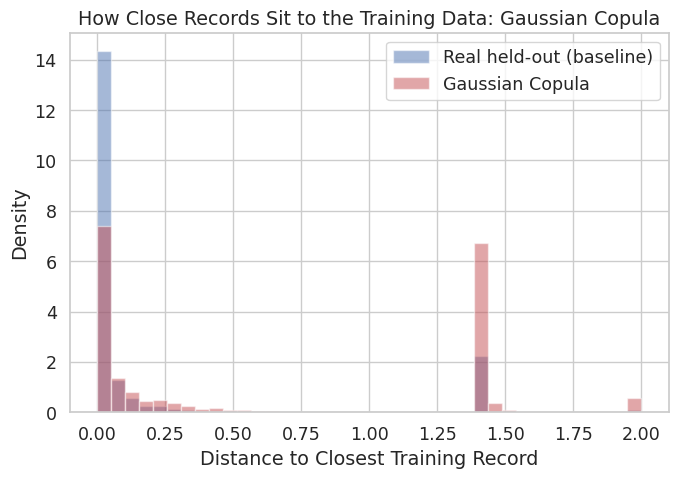

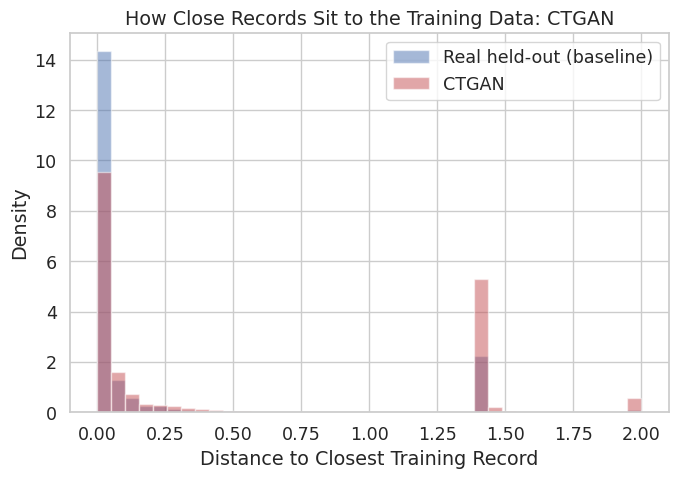

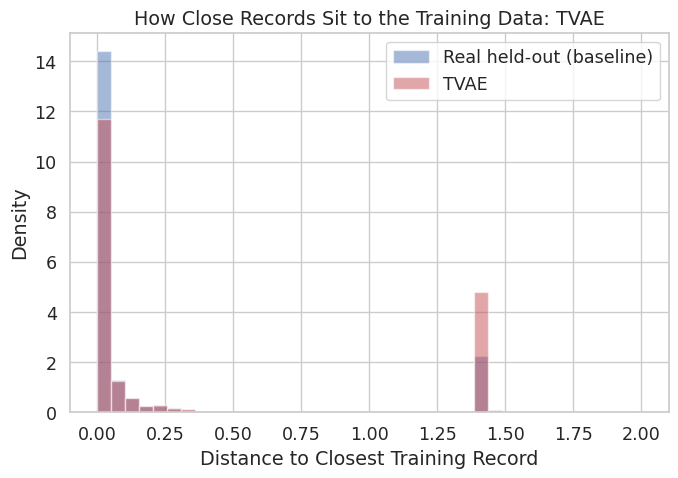

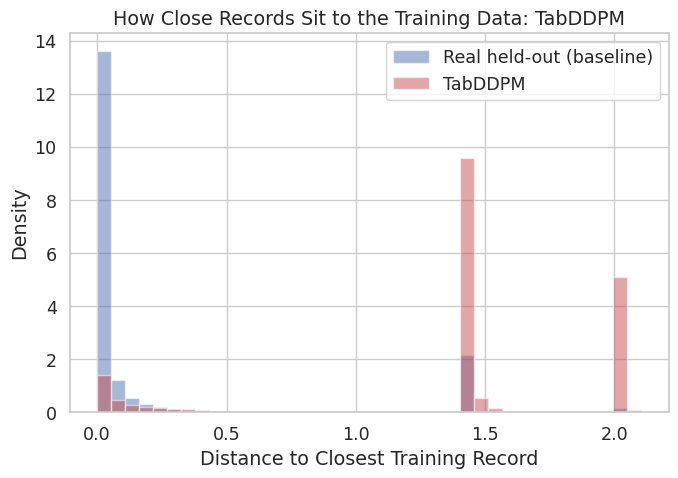

In [18]:
for name, d1 in dcr_store.items():
    fig, ax = plt.subplots(figsize=(7, 5))
    upper = np.percentile(np.concatenate([holdout_dcr, d1]), 99)
    bins = np.linspace(0, max(upper, 1e-6), 40)
    ax.hist(holdout_dcr, bins=bins, density=True, alpha=0.5, color="#4C72B0", label="Real held-out (baseline)")
    ax.hist(d1, bins=bins, density=True, alpha=0.5, color="#C44E52", label=name)
    ax.set_xlabel("Distance to Closest Training Record")
    ax.set_ylabel("Density")
    ax.set_title(f"How Close Records Sit to the Training Data: {name}")
    ax.legend()
    fig.tight_layout()
    safe = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    fig.savefig(fig_dir / f"privacy_dcr_{safe}.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

Blue shows how close genuinely new patients naturally sit to the training data, red shows the
same for one method's synthetic records. The two overlapping is the healthy outcome. A red
spike at zero that blue does not share would mean many synthetic records are near copies of
individual training records.

### Test 3: membership inference

An attacker holds the synthetic dataset and a target person's record, and wants to know
whether that person was in the generator's training data. The attack logic is standard: if a
record sits unusually close to the synthetic data, guess it was a training member.

The test takes equal numbers of training records and held-out records, scores each by its
distance to the nearest synthetic record, and asks how well that score separates the two
groups. Reported as ROC AUC, where 0.5 means the attacker is guessing at random.

Gaussian Copula: membership inference attack AUC = 0.4998
CTGAN: membership inference attack AUC = 0.4959
TVAE: membership inference attack AUC = 0.5008
TabDDPM: membership inference attack AUC = 0.4942


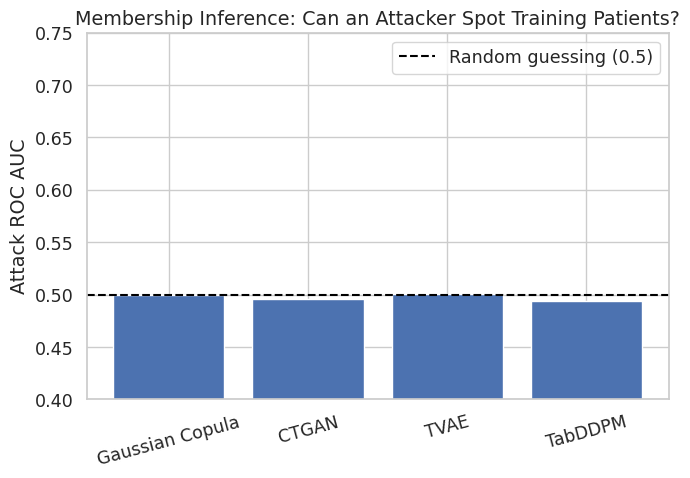

In [19]:
members = train_df.sample(n=min(N_ATTACK, len(train_df)), random_state=SEED)
non_members = test_df.sample(n=min(N_ATTACK, len(test_df)), random_state=SEED)
targets = pd.concat([members, non_members], ignore_index=True)
labels = np.concatenate([np.ones(len(members)), np.zeros(len(non_members))])
targets_encoded = encode(targets)

attack_rows = []
for name, syn in synthetic.items():
    syn_ref = syn.sample(n=min(N_TRAIN_REF, len(syn)), random_state=SEED)
    syn_nn = NearestNeighbors(n_neighbors=1).fit(encode(syn_ref))
    dists, _ = syn_nn.kneighbors(targets_encoded)
    # Closer to the synthetic data means a higher membership score.
    attack_auc = roc_auc_score(labels, -dists[:, 0])
    attack_rows.append({"method": name, "membership_attack_auc": attack_auc})
    print(f"{name}: membership inference attack AUC = {attack_auc:.4f}")

attack_df = pd.DataFrame(attack_rows).round(4)
attack_df.to_csv(out_dir / "privacy_membership_inference.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(attack_df["method"], attack_df["membership_attack_auc"], color="#4C72B0")
ax.axhline(0.5, color="black", linestyle="--", label="Random guessing (0.5)")
ax.set_ylabel("Attack ROC AUC")
ax.set_title("Membership Inference: Can an Attacker Spot Training Patients?")
# Upper limit follows the data. A fixed ceiling would hide the one result that matters
# most here, an attack scoring well above chance.
ax.set_ylim(0.4, max(0.75, float(attack_df["membership_attack_auc"].max()) + 0.05))
ax.tick_params(axis="x", rotation=15)
ax.legend()
fig.tight_layout()
fig.savefig(fig_dir / "privacy_membership_inference.png", dpi=200, bbox_inches="tight")
plt.show()

Bars on the dashed line mean the attacker does no better than a coin flip, the outcome that
supports a privacy claim. The further a bar rises above it, the more that method gives away
about who was in its training set. Even small rises matter in a healthcare context, because
simply being in a hospital dataset is itself sensitive.

### Privacy summary

One row per method, combining the headline number from each of the three tests.

In [20]:
privacy_summary = pd.DataFrame({
    "method": list(synthetic.keys()),
    "exact_match_rate": [dup_df.loc[dup_df.dataset == m, "exact_match_rate"].iloc[0] for m in synthetic],
    "exact_match_baseline": dup_df.loc[dup_df.dataset == "Real held-out data (baseline)", "exact_match_rate"].iloc[0],
    "median_dcr": [nn_df.loc[nn_df.dataset == m, "median_dcr"].iloc[0] for m in synthetic],
    "median_dcr_baseline": nn_df.loc[nn_df.dataset == "Real held-out data (baseline)", "median_dcr"].iloc[0],
    "membership_attack_auc": [attack_df.loc[attack_df.method == m, "membership_attack_auc"].iloc[0] for m in synthetic],
}).round(4)
privacy_summary.to_csv(out_dir / "privacy_summary.csv", index=False)
privacy_summary

,method,exact_match_rate,exact_match_baseline,median_dcr,median_dcr_baseline,membership_attack_auc
0,Gaussian Copula,0.0000,0.1531,0.1919,0.0137,0.4998
1,CTGAN,0.0001,0.1531,0.0552,0.0137,0.4959
2,TVAE,0.0002,0.1531,0.0190,0.0137,0.5008
3,TabDDPM,0.0000,0.1531,1.4153,0.0137,0.4942


## Part 4: The trade-off

No single dimension decides whether a synthetic method is good. A generator can buy high
fidelity and utility by memorising its training data, which the privacy tests would then
expose. Another can reproduce every column's shape perfectly while losing the relationships
between them, which the utility test exposes. The table brings the headline number from each
dimension together, one row per dataset, so each method appears twice, so the whole profile can be read at a glance.

The columns are the loss in ROC AUC against the real-data baseline and the same figure as a
percentage of it; mean KS across the numeric columns and mean TVD across the categorical
ones, both reported because no method leads on both; the median distance to the closest
training record and the membership inference attack AUC; whether the method met the success
criterion; and training and generation time from the shared log.

Cost belongs here rather than in a footnote. A method that matches another on all three
quality dimensions while costing a fraction of the compute is the better practical choice,
and that conclusion is only reachable if the two sit side by side. The timings are single
runs on hardware that varied between sessions, so they should be read as orders of magnitude
rather than precise benchmarks.

In [21]:
tradeoff = pd.DataFrame({
    "method": list(synthetic.keys()),
    # Utility: how much predictive signal was lost (lower is better)
    "utility_loss_roc_auc": [
        utility_df.loc[utility_df.method == m, "utility_loss_roc_auc"].iloc[0] for m in synthetic
    ],
    "pct_of_baseline_roc_auc": [
        utility_df.loc[utility_df.method == m, "pct_of_baseline_roc_auc"].iloc[0] for m in synthetic
    ],
    # PR AUC sits beside ROC AUC because the outcome is rare. A generator that
    # under-represents the positive class loses more PR AUC than ROC AUC, so the two can
    # disagree, and where they do the disagreement is the finding rather than a nuisance.
    "tstr_pr_auc": [
        utility_df.loc[utility_df.method == m, "tstr_pr_auc"].iloc[0] for m in synthetic
    ],
    "utility_loss_pr_auc": [
        utility_df.loc[utility_df.method == m, "utility_loss_pr_auc"].iloc[0] for m in synthetic
    ],
    # Fidelity: numeric and categorical, since no method leads on both
    "mean_ks_numeric": [
        fidelity_summary.loc[fidelity_summary.method == m, "mean_ks_numeric"].iloc[0] for m in synthetic
    ],
    "mean_tvd_categorical": [
        fidelity_summary.loc[fidelity_summary.method == m, "mean_tvd_categorical"].iloc[0] for m in synthetic
    ],
    # Privacy: distance to the training data, and the attack result
    "median_dcr": [
        privacy_summary.loc[privacy_summary.method == m, "median_dcr"].iloc[0] for m in synthetic
    ],
    "membership_attack_auc": [
        privacy_summary.loc[privacy_summary.method == m, "membership_attack_auc"].iloc[0] for m in synthetic
    ],
})

# The Chapter 3 verdict, so the table answers the research question directly.
tradeoff = tradeoff.merge(criterion[["method", "verdict"]], on="method", how="left")

# Computational cost is the fourth dimension of the comparison and until now has
# lived in a separate file written by the generation notebooks. Folding it in here
# gives one row per method across all four dimensions, which is the table the
# results chapter is built around.
log_path = out_dir / "generation_log.csv"
if log_path.exists():
    generation_log = pd.read_csv(log_path)
    # The log is keyed on method and experiment separately, while everything here is keyed
    # on the dataset label. Rebuild that label so the two join. Rows with no experiment
    # predate the two-experiment structure and are ignored rather than matched.
    if "experiment" in generation_log.columns:
        generation_log = generation_log[generation_log["experiment"].notna()].copy()
        generation_log["method"] = (
            generation_log["method"] + " (" + generation_log["experiment"].astype(str) + ")"
        )
    generation_log = (
        generation_log[["method", "train_seconds", "generate_seconds"]]
        .drop_duplicates(subset="method", keep="last")
    )
    tradeoff = tradeoff.merge(generation_log, on="method", how="left")
    missing = tradeoff.loc[tradeoff["train_seconds"].isna(), "method"].tolist()
    if missing:
        print(
            "No timings recorded for: " + ", ".join(missing) +
            ". Re-run the generating notebook's final cell to add them.\n"
        )
    tradeoff["total_seconds"] = tradeoff["train_seconds"] + tradeoff["generate_seconds"]
    tradeoff["total_minutes"] = (tradeoff["total_seconds"] / 60).round(1)
else:
    print(
        f"{log_path} not found, so the cost columns are omitted. Re-run the generation "
        "notebooks to produce it."
    )

tradeoff = tradeoff.sort_values("utility_loss_roc_auc").reset_index(drop=True)
tradeoff = tradeoff.round(4)
tradeoff.to_csv(out_dir / "tradeoff_summary.csv", index=False)

if "total_minutes" in tradeoff.columns:
    cheapest = tradeoff.loc[tradeoff["total_minutes"].idxmin()]
    dearest = tradeoff.loc[tradeoff["total_minutes"].idxmax()]
    print(
        f"Cost spread: {cheapest['method']} at {cheapest['total_minutes']:.1f} min "
        f"vs {dearest['method']} at {dearest['total_minutes']:.1f} min "
        f"({dearest['total_minutes'] / max(cheapest['total_minutes'], 1e-9):.0f}x).\n"
    )

tradeoff

Cost spread: Gaussian Copula at 1.9 min vs TabDDPM at 167.9 min (88x).



,method,utility_loss_roc_auc,pct_of_baseline_roc_auc,mean_ks_numeric,mean_tvd_categorical,median_dcr,membership_attack_auc,verdict,train_seconds,generate_seconds,total_seconds,total_minutes
0,CTGAN,0.0350,94.2874,0.0456,0.0878,0.0552,0.4959,PASS,6724.9,5.5,6730.4,112.2
1,Gaussian Copula,0.0373,93.9166,0.0583,0.0012,0.1919,0.4998,PASS,105.5,7.3,112.8,1.9
2,TVAE,0.0463,92.4366,0.0312,0.0465,0.0190,0.5008,PASS,4223.3,3.1,4226.4,70.4
3,TabDDPM,0.0906,85.2131,0.2206,0.1786,1.4153,0.4942,FAIL,9809.1,264.0,10073.1,167.9


Reading across a row gives one method's full profile; reading down a column ranks the methods
on one dimension. A method is only interesting if it holds up across all of them, since
strength on utility or fidelity alone can come at the cost of privacy.

## Downloading the outputs

Two separate archives rather than one. Result tables and figures are used differently, tables
being read and quoted while figures are placed into the document, so mixing them into a single
archive makes both harder to work with.

In [ ]:
try:
    import google.colab  # noqa: F401
    IN_NOTEBOOK_SERVICE = True
except ImportError:
    IN_NOTEBOOK_SERVICE = False

if IN_NOTEBOOK_SERVICE:
    import base64
    import shutil
    from IPython.display import HTML, display

    def build_archive(name, source_dir, pattern):
        """Collect matching files into a named archive and offer it as a download link."""
        staging = Path(f"download_{name}")
        if staging.exists():
            shutil.rmtree(staging)
        staging.mkdir()

        files = sorted(source_dir.glob(pattern))
        for f in files:
            shutil.copy(f, staging)

        if not files:
            print(f"{name}: nothing matching {pattern} in {source_dir}, skipped")
            shutil.rmtree(staging)
            return

        archive = shutil.make_archive(name, "zip", staging)
        shutil.rmtree(staging)
        size_mb = Path(archive).stat().st_size / 1_048_576
        with open(archive, "rb") as fh:
            encoded = base64.b64encode(fh.read()).decode()
        display(HTML(
            f'<p style="font-size:15px;"><a download="{name}.zip" '
            f'href="data:application/zip;base64,{encoded}">Download {name}.zip</a> '
            f'({len(files)} files, {size_mb:.1f} MB)</p>'
        ))

    build_archive("results_tables", out_dir, "*.csv")
    build_archive("results_figures", fig_dir, "*.png")
else:
    print(f"Tables are in {out_dir.resolve()}")
    print(f"Figures are in {fig_dir.resolve()}")

## Results

All three evaluation dimensions are now measured for every method, plus the combined
trade-off table. The tables and figures written here are the evidence base for the results
chapter.